In [46]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, roc_curve, auc,classification_report
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import joblib
import json

from config import DATA_PATH, PROCESSED_DATA_PATH, SENTENCES, MODEL_SAVE_PATH

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

/var/folders/nb/6rxqchpx425dyjql5p01n12w0000gn/T/ipykernel_71618/1911787946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=Y_raw, palette="viridis", order=np.unique(Y_raw))


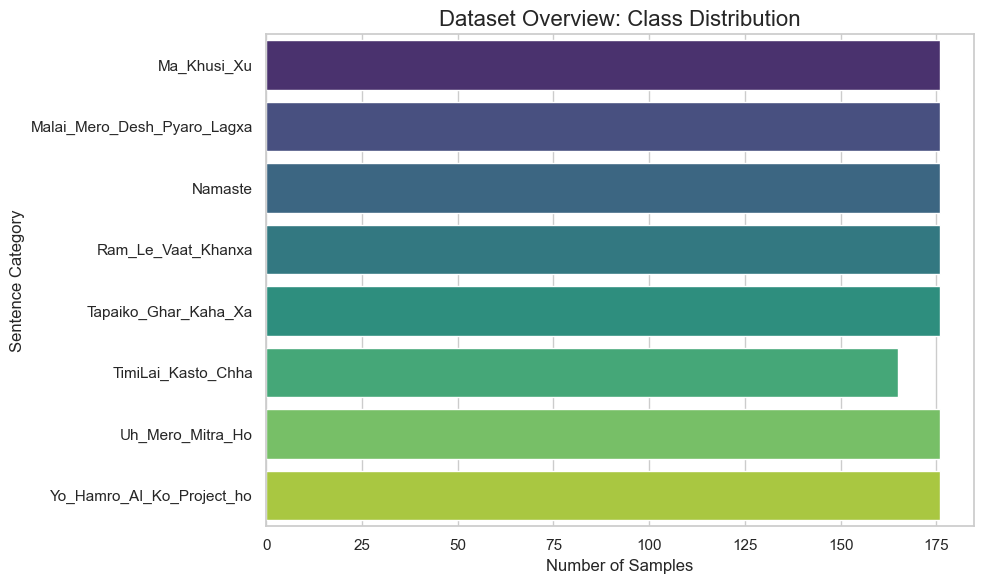

In [53]:
# Load Y.npy to see the class distribution
Y_raw = np.load(os.path.join(PROCESSED_DATA_PATH, 'Y.npy'))

plt.figure(figsize=(10, 6))
sns.countplot(y=Y_raw, palette="viridis", order=np.unique(Y_raw))
plt.title('Dataset Overview: Class Distribution', fontsize=16)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Sentence Category', fontsize=12)
plt.tight_layout()
plt.show()

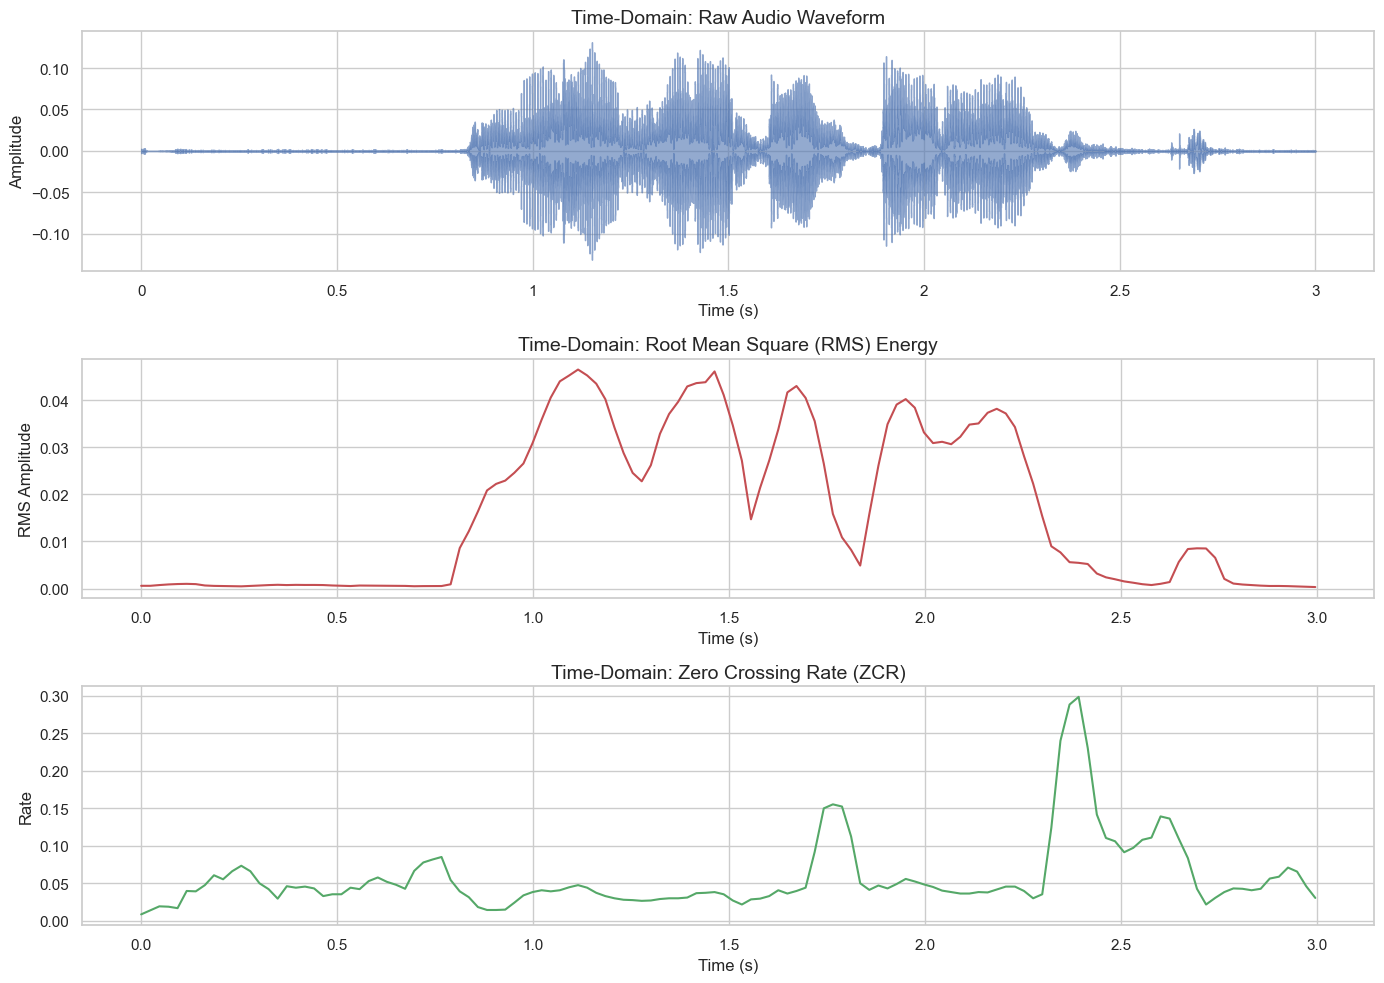

In [54]:
# Load a sample audio file
SAMPLE_AUDIO_PATH="/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/data/raw/Malai_Mero_Desh_Pyaro_Lagxa/sk01_s02.wav"
audio, sr = librosa.load(SAMPLE_AUDIO_PATH, sr=22050)

plt.figure(figsize=(14, 10))

# 1. Raw Audio Waveform
plt.subplot(3, 1, 1)
librosa.display.waveshow(audio, sr=sr, alpha=0.6)
plt.title('Time-Domain: Raw Audio Waveform', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# 2. RMS Energy
rms = librosa.feature.rms(y=audio, frame_length=2048, hop_length=512)[0]
frames = range(len(rms))
t = librosa.frames_to_time(frames, hop_length=512, sr=sr)
plt.subplot(3, 1, 2)
plt.plot(t, rms, color='r')
plt.title('Time-Domain: Root Mean Square (RMS) Energy', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('RMS Amplitude')

# 3. Zero Crossing Rate (ZCR)
zcr = librosa.feature.zero_crossing_rate(y=audio, frame_length=2048, hop_length=512)[0]
plt.subplot(3, 1, 3)
plt.plot(t, zcr, color='g')
plt.title('Time-Domain: Zero Crossing Rate (ZCR)', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Rate')

plt.tight_layout()
plt.show()

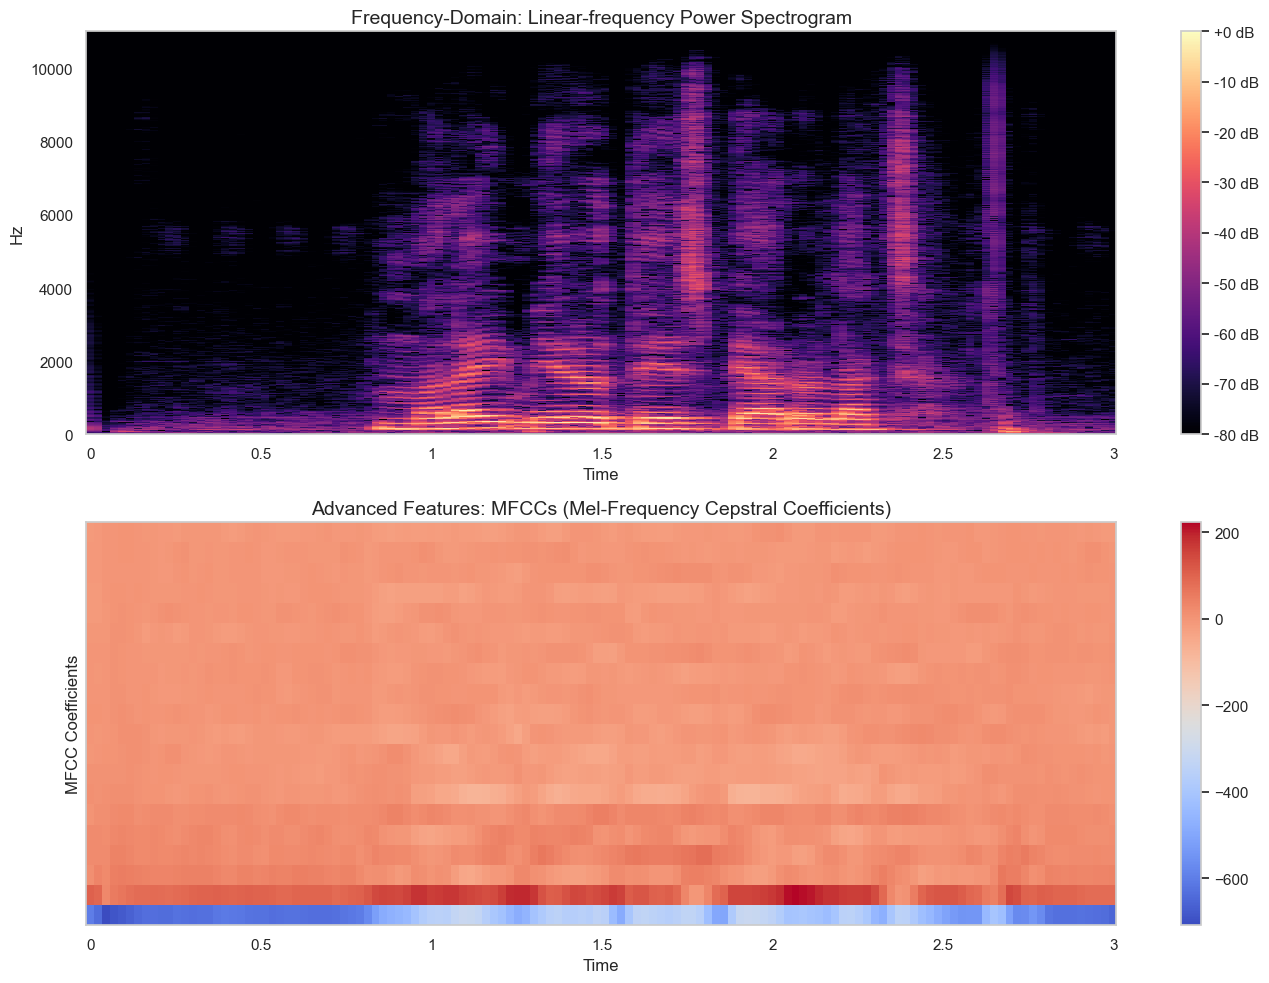

In [55]:
plt.figure(figsize=(14, 10))

# 1. Spectrogram (Frequency Domain)
# Convert to decibels for better visualization
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
plt.subplot(2, 1, 1)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Frequency-Domain: Linear-frequency Power Spectrogram', fontsize=14)

# 2. Mel-Frequency Cepstral Coefficients (MFCCs - Advanced Features)
# Note: Using n_mfcc=20 to match your data_prep.py default
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)
plt.subplot(2, 1, 2)
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title('Advanced Features: MFCCs (Mel-Frequency Cepstral Coefficients)', fontsize=14)
plt.ylabel('MFCC Coefficients')

plt.tight_layout()
plt.show()

Loading artifacts and data...


/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/.venv-1/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/.venv-1/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Scaling sequential features...
Generating predictions...
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step
Confusion matrix saved successfully as 'confusion_matrix_result.png'!


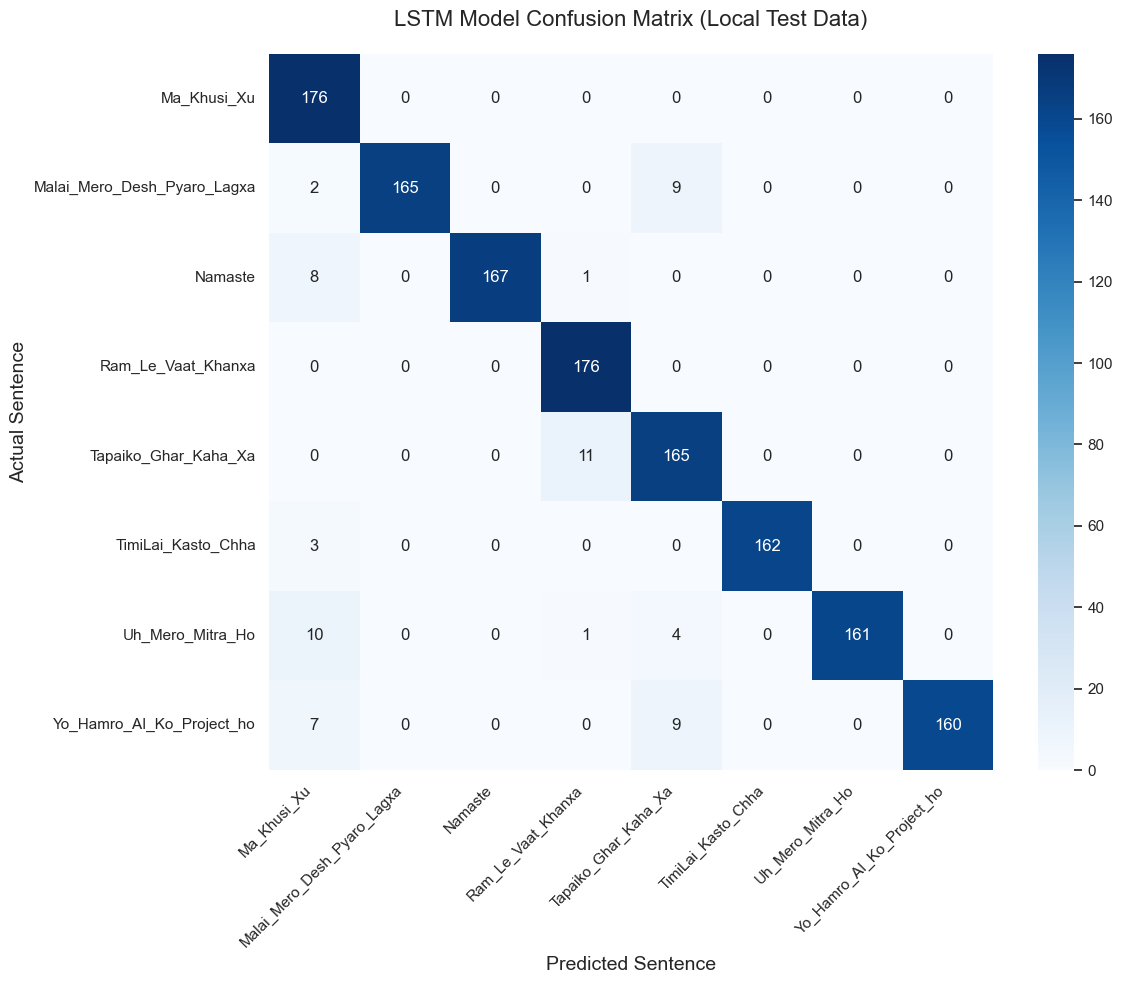

In [52]:
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model

# --- PATHS ---
DATA_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/data/processed"
MODEL_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/nepali_lstm_model.h5"
SCALER_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/scaler.joblib"
ENCODER_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/label_encoder.joblib"

def plot_local_confusion_matrix():
    print("Loading artifacts and data...")
    try:
        X_test = np.load(os.path.join(PROCESSED_DATA_PATH, 'X.npy'))
        Y_true = np.load(os.path.join(PROCESSED_DATA_PATH, 'Y.npy'))
    except FileNotFoundError:
        print("Error: Could not find X.npy or Y.npy.")
        return

    model = load_model(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    label_encoder = joblib.load(ENCODER_PATH)

    # 1. Check Dimensions
    # The LSTM expects (Samples, Time_Steps, Features) e.g., (N, 182, 15)
    if len(X_test.shape) != 3:
        print(f"ERROR: Expected 3D data (samples, time_steps, features), got {X_test.shape}.")
        print("Please re-extract your test features using the new 'process_audio_sequence' function!")
        return

    # 2. Scale the Data
    print("Scaling sequential features...")
    samples, time_steps, features = X_test.shape
    
    # Reshape to 2D for the scaler, then back to 3D
    X_test_2d = X_test.reshape(-1, features)
    X_test_scaled_2d = scaler.transform(X_test_2d)
    X_test_scaled = X_test_scaled_2d.reshape(samples, time_steps, features)

    # 3. Predict
    print("Generating predictions...")
    prediction_probs = model.predict(X_test_scaled)
    predicted_indices = np.argmax(prediction_probs, axis=1)
    
    # Encode Y_true strings to indices to compare with predictions
    true_indices = label_encoder.transform(Y_true)
    class_names = label_encoder.classes_

    # 4. Compute Confusion Matrix
    cm = confusion_matrix(true_indices, predicted_indices)

    # 5. Plot
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('LSTM Model Confusion Matrix (Local Test Data)', fontsize=16, pad=20)
    plt.ylabel('Actual Sentence', fontsize=14)
    plt.xlabel('Predicted Sentence', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Save the plot as an image instead of just showing it
    save_path = "confusion_matrix_result.png"
    plt.savefig(save_path)
    print(f"Confusion matrix saved successfully as '{save_path}'!")
    plt.show()

if __name__ == "__main__":
    plot_local_confusion_matrix()